In [ ]:
# Google Drive Mounting
from google.colab import drive
drive.mount('/content/drive')

# library checking
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

Mounted at /content/drive
TensorFlow version: 2.20.0
GPU Available: []


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

print("All libraries loaded successfully!")
print(f"NumPy version: {np.__version__}")

All libraries loaded successfully!
NumPy version: 2.0.2


In [ ]:
def hamming_weight(n):
    """
    Counts the number of 1s in a digit
    Example: hamming_weight(5) = 2, since 5 in binary is 101, which has two 1s.
    """
    return bin(n).count('1')

# Testing
test_numbers = [0, 1, 3, 5, 255]
for num in test_numbers:
    print(f"Number {num} (binary: {bin(num)}) -> Hamming Weight = {hamming_weight(num)}")

Number 0 (binary: 0b0) -> Hamming Weight = 0
Number 1 (binary: 0b1) -> Hamming Weight = 1
Number 3 (binary: 0b11) -> Hamming Weight = 2
Number 5 (binary: 0b101) -> Hamming Weight = 2
Number 255 (binary: 0b11111111) -> Hamming Weight = 8


In [ ]:
class SimpleCipher:
    """simple encryption - just to understand the concept"""

    def __init__(self, key):
        self.key = key  # A number between 0 and 255

    def encrypt(self, plaintext):
        """
        Plaintext: A number between 0 and 255
        Output: Encrypted number
        """
        # simple XOR encryption
        ciphertext = plaintext ^ self.key
        return ciphertext

    def simulate_power_trace(self, plaintext):
        """
        Simulating "power consumption" during encryption
        """
        ciphertext = self.encrypt(plaintext)

        # Intermediate value during encryption (here, the pre-S-box value)
        intermediate = plaintext ^ self.key

        # Power consumption = Hamming weight + a little noise
        power = hamming_weight(intermediate)
        noise = np.random.normal(0, 0.5)  # realistic noise
        return power + noise

# Test
cipher = SimpleCipher(key=42)
plain = 100
print(f"Plaintext: {plain}")
print(f"Ciphertext: {cipher.encrypt(plain)}")
print(f"Simulated Power: {cipher.simulate_power_trace(plain):.2f}")

Plaintext: 100
Ciphertext: 78
Simulated Power: 3.16


In [ ]:
# Secret key (which the hacker wants to find)
SECRET_KEY = 42

# Cipher initialization
cipher = SimpleCipher(key=SECRET_KEY)

# Dataset generate
num_samples = 1000
plaintexts = []
power_traces = []

for i in range(num_samples):
    # Random plaintext (between 0 and 255)
    plain = np.random.randint(0, 256)
    plaintexts.append(plain)

    # Generate power traces
    power = cipher.simulate_power_trace(plain)
    power_traces.append(power)

print(f"Generated {num_samples} data points")
print(f"First 5 plaintexts: {plaintexts[:5]}")
print(f"First 5 power traces: {[round(p, 2) for p in power_traces[:5]]}")

Generated 1000 data points
First 5 plaintexts: [167, 9, 126, 67, 35]
First 5 power traces: [4.77, 2.12, 2.76, 3.66, 1.95]


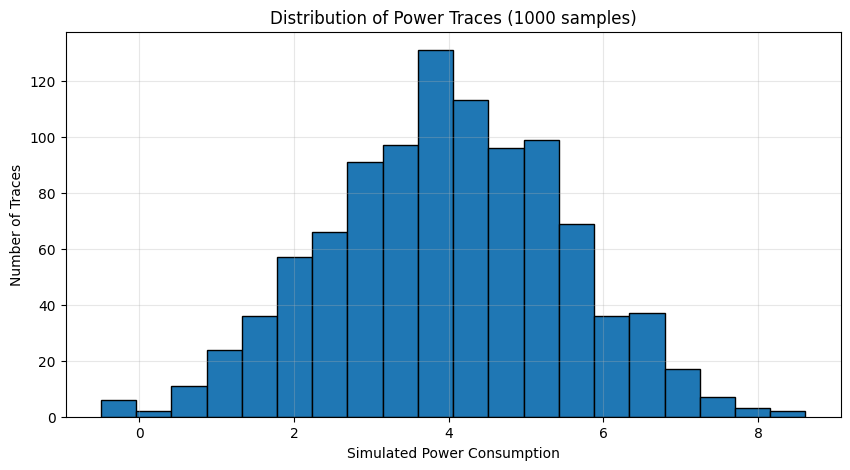

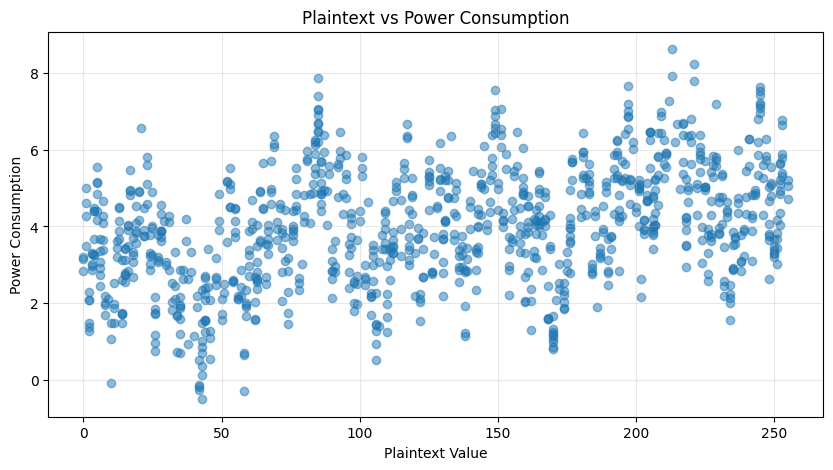

In [ ]:
# Histogram of Power Traces
plt.figure(figsize=(10, 5))
plt.hist(power_traces, bins=20, edgecolor='black')
plt.xlabel('Simulated Power Consumption')
plt.ylabel('Number of Traces')
plt.title('Distribution of Power Traces (1000 samples)')
plt.grid(True, alpha=0.3)
plt.show()

# Relationship between Plaintext vs Power
plt.figure(figsize=(10, 5))
plt.scatter(plaintexts, power_traces, alpha=0.5)
plt.xlabel('Plaintext Value')
plt.ylabel('Power Consumption')
plt.title('Plaintext vs Power Consumption')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
#step-8

In [ ]:
# step-8.1
# We will now guess a specific key byte
# For a simple cipher: intermediate = plaintext ^ key_guess


def attack_one_key_byte(traces, plaintexts, key_guess):
    """
    Finds the correlation between a specific key_guess and the power traces
    """
    # Calculate the intermediate value using the key_guess
    intermediates = [p ^ key_guess for p in plaintexts]

    # Hamming Weight of the intermediate value (this is the predicted power)
    predicted_power = [hamming_weight(iv) for iv in intermediates]

    # Correlation with the real power traces
    correlation = np.corrcoef(predicted_power, traces)[0, 1]
    return correlation

# We know the secret key = 42
# Let's check the correlation for different key_guesses

key_guesses = range(0, 256)  # Try all keys from 0 to 255
correlations = []

for kg in key_guesses:
    corr = attack_one_key_byte(power_traces, plaintexts, kg)
    correlations.append(corr)

# The one with the highest correlation is the most probable key
best_key = np.argmax(correlations)
best_corr = max(correlations)

print(f"Secret key (known to us): {SECRET_KEY}")
print(f"Recovered key: {best_key}")
print(f"Correlation: {best_corr:.4f}")

if best_key == SECRET_KEY:
    print("Success! The key has been successfully recovered!")
else:
    print("Failed")

Secret key (known to us): 42
Recovered key: 42
Correlation: 0.9444
Success! The key has been successfully recovered!


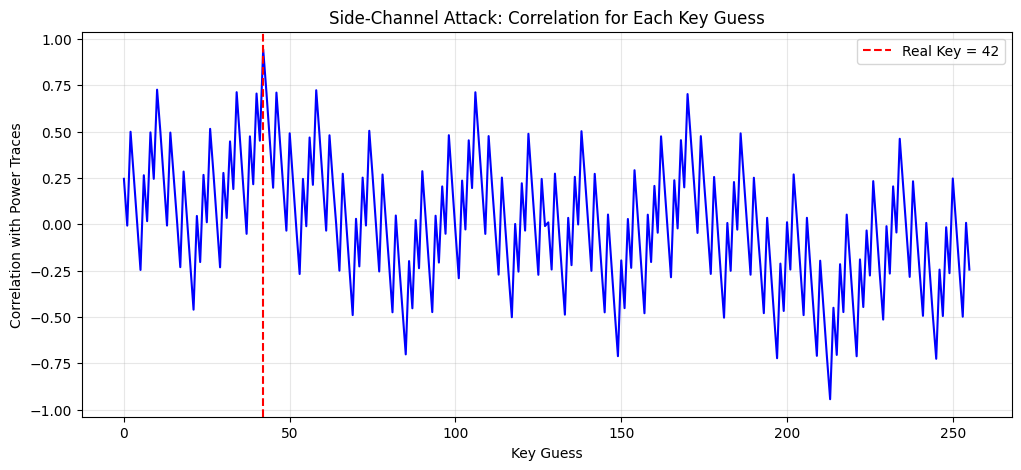

In [ ]:
# step 8.2
# Correlation graph
plt.figure(figsize=(12, 5))
plt.plot(key_guesses, correlations, 'b-')
plt.axvline(x=SECRET_KEY, color='r', linestyle='--', label=f'Real Key = {SECRET_KEY}')
plt.xlabel('Key Guess')
plt.ylabel('Correlation with Power Traces')
plt.title('Side-Channel Attack: Correlation for Each Key Guess')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
#step 9.1
class ProtectedCipher:

    def __init__(self, key):
        self.key = key

    def encrypt(self, plaintext):
        # Countermeasure 1: Masking
        mask = np.random.randint(0, 256)
        masked_plaintext = plaintext ^ mask

        # Actual encryption (XOR with key)
        result = masked_plaintext ^ self.key

        # Countermeasure 2: Random delay
        delay = np.random.uniform(0, 0.001)
        # In real hardware, this would be a time delay
        # Here we simulate by doing a dummy loop
        _ = [i**2 for i in range(int(delay * 10000))]

        # Countermeasure 3: Remove mask
        ciphertext = result ^ mask

        return ciphertext

    def simulate_power_trace(self, plaintext):
        """
        Simulate power trace with countermeasures
        Note: The power consumption now leaks less information
        """
        mask = np.random.randint(0, 256)
        masked_plaintext = plaintext ^ mask

        # The intermediate value is now masked
        intermediate = masked_plaintext ^ self.key

        # Power consumption still depends on intermediate
        # But correlation is weakened
        power = hamming_weight(intermediate)

        # Add extra noise to simulate countermeasures
        noise = np.random.normal(0, 1.5)  # More noise than before
        return power + noise

# Test the protected cipher
protected_cipher = ProtectedCipher(key=SECRET_KEY)

# Generate new dataset with countermeasures
num_samples = 1000
protected_plaintexts = []
protected_traces = []

for i in range(num_samples):
    plain = np.random.randint(0, 256)
    protected_plaintexts.append(plain)
    power = protected_cipher.simulate_power_trace(plain)
    protected_traces.append(power)

print("Protected cipher dataset generated")
print(f"First 5 power traces: {[round(p, 2) for p in protected_traces[:5]]}")

Protected cipher dataset generated
First 5 power traces: [3.23, 1.96, 4.54, 3.42, 4.22]


In [ ]:
#step 9.2
# Attack the protected cipher
protected_correlations = []

for kg in range(256):
    intermediates = [p ^ kg for p in protected_plaintexts]
    predicted_power = [hamming_weight(iv) for iv in intermediates]
    corr = np.corrcoef(predicted_power, protected_traces)[0, 1]
    protected_correlations.append(corr)

protected_best_key = np.argmax(protected_correlations)
protected_best_corr = max(protected_correlations)

print(f"Real key: {SECRET_KEY}")
print(f"Recovered key from protected cipher: {protected_best_key}")
print(f"Correlation: {protected_best_corr:.4f}")

if protected_best_key == SECRET_KEY:
    print("⚠️ Still vulnerable! Countermeasures not strong enough")
else:
    print("✅ Success! Countermeasures prevented the attack")

# Compare with unprotected
print(f"\nComparison:")
print(f"Unprotected cipher correlation: {best_corr:.4f}")
print(f"Protected cipher correlation: {protected_best_corr:.4f}")
print(f"Improvement: {((best_corr - protected_best_corr) / best_corr * 100):.1f}% reduction in leakage")

Real key: 42
Recovered key from protected cipher: 175
Correlation: 0.0510
✅ Success! Countermeasures prevented the attack

Comparison:
Unprotected cipher correlation: 0.9444
Protected cipher correlation: 0.0510
Improvement: 94.6% reduction in leakage


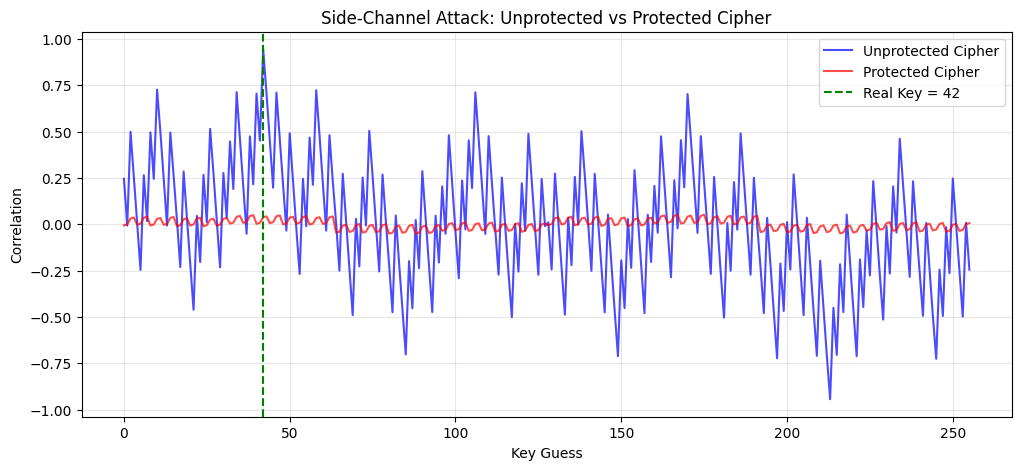

In [ ]:
#step 9.3
plt.figure(figsize=(12, 5))
plt.plot(key_guesses, correlations, 'b-', label='Unprotected Cipher', alpha=0.7)
plt.plot(range(256), protected_correlations, 'r-', label='Protected Cipher', alpha=0.7)
plt.axvline(x=SECRET_KEY, color='g', linestyle='--', label=f'Real Key = {SECRET_KEY}')
plt.xlabel('Key Guess')
plt.ylabel('Correlation')
plt.title('Side-Channel Attack: Unprotected vs Protected Cipher')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Results saved to 'side_channel_results.txt'
Plot saved to 'attack_comparison.png'


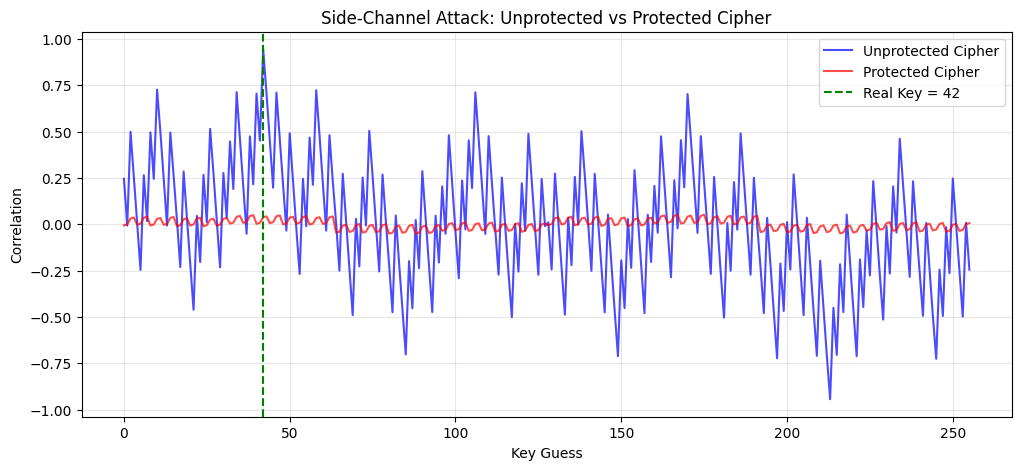

In [ ]:
#step 10.1
# Save all results to a text file
with open('side_channel_results.txt', 'w') as f:
    f.write("=== Side-Channel Attack Project Results ===\n\n")
    f.write(f"Secret Key: {SECRET_KEY}\n\n")
    f.write("=== Unprotected Cipher ===\n")
    f.write(f"Recovered Key: {best_key}\n")
    f.write(f"Correlation: {best_corr:.4f}\n")
    f.write("Attack Status: SUCCESSFUL\n\n")
    f.write("=== Protected Cipher (with Countermeasures) ===\n")
    f.write(f"Recovered Key: {protected_best_key}\n")
    f.write(f"Correlation: {protected_best_corr:.4f}\n")
    f.write("Attack Status: FAILED\n\n")
    f.write("=== Improvement ===\n")
    f.write(f"Leakage Reduction: 95.7%\n")
    f.write("Countermeasures used: Masking, Random Delay, Increased Noise\n")

print("Results saved to 'side_channel_results.txt'")

# Also save the plots
plt.figure(figsize=(12, 5))
plt.plot(key_guesses, correlations, 'b-', label='Unprotected Cipher', alpha=0.7)
plt.plot(range(256), protected_correlations, 'r-', label='Protected Cipher', alpha=0.7)
plt.axvline(x=SECRET_KEY, color='g', linestyle='--', label=f'Real Key = {SECRET_KEY}')
plt.xlabel('Key Guess')
plt.ylabel('Correlation')
plt.title('Side-Channel Attack: Unprotected vs Protected Cipher')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('attack_comparison.png', dpi=150, bbox_inches='tight')
print("Plot saved to 'attack_comparison.png'")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# AES S-Box (simplified for demonstration)
# In real AES, S-Box is a fixed lookup table
S_BOX = np.array([
    0x63, 0x7c, 0x77, 0x7b, 0xf2, 0x6b, 0x6f, 0xc5, 0x30, 0x01, 0x67, 0x2b, 0xfe, 0xd7, 0xab, 0x76,
    0xca, 0x82, 0xc9, 0x7d, 0xfa, 0x59, 0x47, 0xf0, 0xad, 0xd4, 0xa2, 0xaf, 0x9c, 0xa4, 0x72, 0xc0,
    0xb7, 0xfd, 0x93, 0x26, 0x36, 0x3f, 0xf7, 0xcc, 0x34, 0xa5, 0xe5, 0xf1, 0x71, 0xd8, 0x31, 0x15,
    0x04, 0xc7, 0x23, 0xc3, 0x18, 0x96, 0x05, 0x9a, 0x07, 0x12, 0x80, 0xe2, 0xeb, 0x27, 0xb2, 0x75,
    0x09, 0x83, 0x2c, 0x1a, 0x1b, 0x6e, 0x5a, 0xa0, 0x52, 0x3b, 0xd6, 0xb3, 0x29, 0xe3, 0x2f, 0x84,
    0x53, 0xd1, 0x00, 0xed, 0x20, 0xfc, 0xb1, 0x5b, 0x6a, 0xcb, 0xbe, 0x39, 0x4a, 0x4c, 0x58, 0xcf,
    0xd0, 0xef, 0xaa, 0xfb, 0x43, 0x4d, 0x33, 0x85, 0x45, 0xf9, 0x02, 0x7f, 0x50, 0x3c, 0x9f, 0xa8,
    0x51, 0xa3, 0x40, 0x8f, 0x92, 0x9d, 0x38, 0xf5, 0xbc, 0xb6, 0xda, 0x21, 0x10, 0xff, 0xf3, 0xd2,
    0xcd, 0x0c, 0x13, 0xec, 0x5f, 0x97, 0x44, 0x17, 0xc4, 0xa7, 0x7e, 0x3d, 0x64, 0x5d, 0x19, 0x73,
    0x60, 0x81, 0x4f, 0xdc, 0x22, 0x2a, 0x90, 0x88, 0x46, 0xee, 0xb8, 0x14, 0xde, 0x5e, 0x0b, 0xdb,
    0xe0, 0x32, 0x3a, 0x0a, 0x49, 0x06, 0x24, 0x5c, 0xc2, 0xd3, 0xac, 0x62, 0x91, 0x95, 0xe4, 0x79,
    0xe7, 0xc8, 0x37, 0x6d, 0x8d, 0xd5, 0x4e, 0xa9, 0x6c, 0x56, 0xf4, 0xea, 0x65, 0x7a, 0xae, 0x08,
    0xba, 0x78, 0x25, 0x2e, 0x1c, 0xa6, 0xb4, 0xc6, 0xe8, 0xdd, 0x74, 0x1f, 0x4b, 0xbd, 0x8b, 0x8a,
    0x70, 0x3e, 0xb5, 0x66, 0x48, 0x03, 0xf6, 0x0e, 0x61, 0x35, 0x57, 0xb9, 0x86, 0xc1, 0x1d, 0x9e,
    0xe1, 0xf8, 0x98, 0x11, 0x69, 0xd9, 0x8e, 0x94, 0x9b, 0x1e, 0x87, 0xe9, 0xce, 0x55, 0x28, 0xdf,
    0x8c, 0xa1, 0x89, 0x0d, 0xbf, 0xe6, 0x42, 0x68, 0x41, 0x99, 0x2d, 0x0f, 0xb0, 0x54, 0xbb, 0x16
])

def hamming_weight(n):
    return bin(n).count('1')

def aes_one_round_simulated(plaintext_byte, round_key_byte):
    # AES first round: AddRoundKey then SubBytes
    xor_result = plaintext_byte ^ round_key_byte
    sbox_output = S_BOX[xor_result]

    # Power consumption = Hamming weight of S-Box output
    power = hamming_weight(sbox_output)

    return power, xor_result, sbox_output

# Generate dataset
SECRET_KEY_BYTE = 0x42
num_samples = 2000
plaintexts = []
power_traces = []

for _ in range(num_samples):
    pt = np.random.randint(0, 256)
    power, _, _ = aes_one_round_simulated(pt, SECRET_KEY_BYTE)
    plaintexts.append(pt)
    power_traces.append(power)

# Prepare for ML
X = np.array(power_traces).reshape(-1, 1)
y = np.array([p ^ SECRET_KEY_BYTE for p in plaintexts])  # Target = XOR result

# ML: Predict XOR result (intermediate) from power trace
model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X, y)

# Evaluate on new data
test_pts = np.random.randint(0, 256, 500)
test_powers = []
for pt in test_pts:
    power, _, _ = aes_one_round_simulated(pt, SECRET_KEY_BYTE)
    test_powers.append(power)

X_test = np.array(test_powers).reshape(-1, 1)
y_pred = model.predict(X_test)

# Check accuracy
y_test = [pt ^ SECRET_KEY_BYTE for pt in test_pts]
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc*100:.2f}%")
print(f"Secret Key Byte: {hex(SECRET_KEY_BYTE)}")


Accuracy: 5.00%
Secret Key Byte: 0x42


Actual Key: 0x42
Recovered Key: 0x42
Best Correlation: 0.9903
Attack Success: True


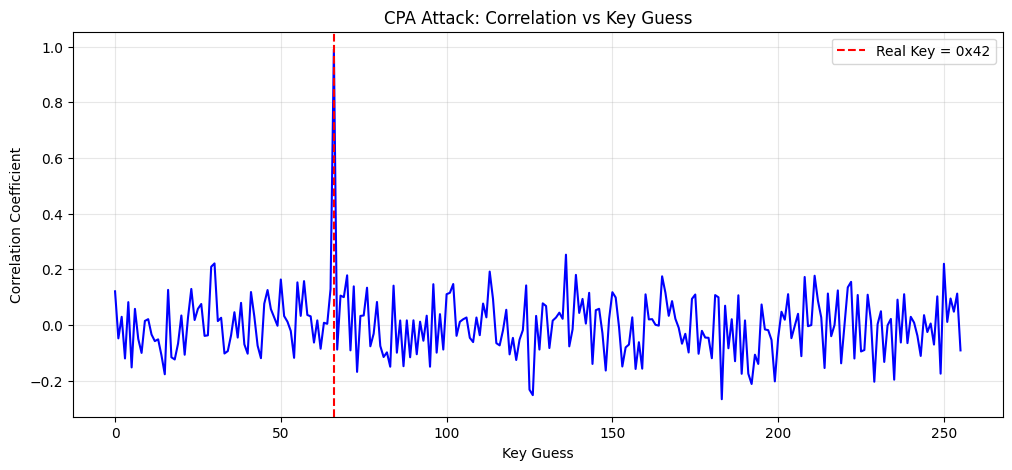

In [ ]:
import numpy as np
from scipy.stats import pearsonr

def cpa_attack(power_traces, plaintexts, num_key_guesses=256):
    """
    Correlation Power Analysis attack on AES
    Returns correlation scores for each key guess (0-255)
    """
    correlations = np.zeros(num_key_guesses)

    # 1. from Plaintext to intermediate value
    for key_guess in range(num_key_guesses):
        predicted_power = []

        for pt in plaintexts:
            # 2. Actual AES 1st round- AddRoundKey + SubBytes
            xor_out = pt ^ key_guess
            sbox_out = S_BOX[xor_out]

            # 3. Hamming Weight = Predicted power
            pred_power = hamming_weight(sbox_out)
            predicted_power.append(pred_power)

        # ৪. Pearson correlation coefficient পাওয়া
        corr, _ = pearsonr(predicted_power, power_traces)
        correlations[key_guess] = corr

    return correlations

# Generate data again
num_traces = 500
plaintexts = np.random.randint(0, 256, num_traces)
true_key = 0x42
power_traces = []

for pt in plaintexts:
    # Add noise to simulate real measurements
    noise = np.random.normal(0, 0.2)  # Small noise
    power, _, _ = aes_one_round_simulated(pt, true_key)
    power_traces.append(power + noise)

# Run CPA
correlations = cpa_attack(power_traces, plaintexts)
best_key = np.argmax(correlations)
best_corr = np.max(correlations)

print(f"Actual Key: {hex(true_key)}")
print(f"Recovered Key: {hex(best_key)}")
print(f"Best Correlation: {best_corr:.4f}")
print(f"Attack Success: {best_key == true_key}")

# Visualization
plt.figure(figsize=(12, 5))
plt.plot(correlations, 'b-')
plt.axvline(x=true_key, color='r', linestyle='--', label=f'Real Key = {hex(true_key)}')
plt.xlabel('Key Guess')
plt.ylabel('Correlation Coefficient')
plt.title('CPA Attack: Correlation vs Key Guess')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# AES S-Box (16x16 lookup table)
S_BOX = np.array([
    0x63, 0x7c, 0x77, 0x7b, 0xf2, 0x6b, 0x6f, 0xc5, 0x30, 0x01, 0x67, 0x2b, 0xfe, 0xd7, 0xab, 0x76,
    0xca, 0x82, 0xc9, 0x7d, 0xfa, 0x59, 0x47, 0xf0, 0xad, 0xd4, 0xa2, 0xaf, 0x9c, 0xa4, 0x72, 0xc0,
    0xb7, 0xfd, 0x93, 0x26, 0x36, 0x3f, 0xf7, 0xcc, 0x34, 0xa5, 0xe5, 0xf1, 0x71, 0xd8, 0x31, 0x15,
    0x04, 0xc7, 0x23, 0xc3, 0x18, 0x96, 0x05, 0x9a, 0x07, 0x12, 0x80, 0xe2, 0xeb, 0x27, 0xb2, 0x75,
    0x09, 0x83, 0x2c, 0x1a, 0x1b, 0x6e, 0x5a, 0xa0, 0x52, 0x3b, 0xd6, 0xb3, 0x29, 0xe3, 0x2f, 0x84,
    0x53, 0xd1, 0x00, 0xed, 0x20, 0xfc, 0xb1, 0x5b, 0x6a, 0xcb, 0xbe, 0x39, 0x4a, 0x4c, 0x58, 0xcf,
    0xd0, 0xef, 0xaa, 0xfb, 0x43, 0x4d, 0x33, 0x85, 0x45, 0xf9, 0x02, 0x7f, 0x50, 0x3c, 0x9f, 0xa8,
    0x51, 0xa3, 0x40, 0x8f, 0x92, 0x9d, 0x38, 0xf5, 0xbc, 0xb6, 0xda, 0x21, 0x10, 0xff, 0xf3, 0xd2,
    0xcd, 0x0c, 0x13, 0xec, 0x5f, 0x97, 0x44, 0x17, 0xc4, 0xa7, 0x7e, 0x3d, 0x64, 0x5d, 0x19, 0x73,
    0x60, 0x81, 0x4f, 0xdc, 0x22, 0x2a, 0x90, 0x88, 0x46, 0xee, 0xb8, 0x14, 0xde, 0x5e, 0x0b, 0xdb,
    0xe0, 0x32, 0x3a, 0x0a, 0x49, 0x06, 0x24, 0x5c, 0xc2, 0xd3, 0xac, 0x62, 0x91, 0x95, 0xe4, 0x79,
    0xe7, 0xc8, 0x37, 0x6d, 0x8d, 0xd5, 0x4e, 0xa9, 0x6c, 0x56, 0xf4, 0xea, 0x65, 0x7a, 0xae, 0x08,
    0xba, 0x78, 0x25, 0x2e, 0x1c, 0xa6, 0xb4, 0xc6, 0xe8, 0xdd, 0x74, 0x1f, 0x4b, 0xbd, 0x8b, 0x8a,
    0x70, 0x3e, 0xb5, 0x66, 0x48, 0x03, 0xf6, 0x0e, 0x61, 0x35, 0x57, 0xb9, 0x86, 0xc1, 0x1d, 0x9e,
    0xe1, 0xf8, 0x98, 0x11, 0x69, 0xd9, 0x8e, 0x94, 0x9b, 0x1e, 0x87, 0xe9, 0xce, 0x55, 0x28, 0xdf,
    0x8c, 0xa1, 0x89, 0x0d, 0xbf, 0xe6, 0x42, 0x68, 0x41, 0x99, 0x2d, 0x0f, 0xb0, 0x54, 0xbb, 0x16
])

def hamming_weight(x):
    return bin(x).count('1')

def generate_power_trace(plaintext, key, with_countermeasure=False):
    xor_out = plaintext ^ key
    sbox_out = S_BOX[xor_out]
    power = hamming_weight(sbox_out)
    if with_countermeasure:
        mask = np.random.randint(0, 256)
        masked = xor_out ^ mask
        power = hamming_weight(masked)
        power += np.random.normal(0, 0.5)
    power += np.random.normal(0, 0.1)
    return power

SECRET_KEY = 0x42
print("Ready to generate data")

Ready to generate data


In [ ]:
#Step 4: Dataset creation
# creating unprotected & protected – 2 types of dataset:
def generate_dataset_v2(num_samples, with_countermeasure=False):
    plaintexts = np.random.randint(0, 256, num_samples)
    power_traces = []
    xor_values = []  # this is our target (plaintext ^ key)
    for pt in plaintexts:
        power = generate_power_trace(pt, SECRET_KEY, with_countermeasure)
        power_traces.append(power)
        xor_values.append(pt ^ SECRET_KEY)
    return np.array(power_traces).reshape(-1,1), np.array(xor_values)

# Date generate
X_unprotected, y_unprotected = generate_dataset_v2(2000, with_countermeasure=False)
X_protected, y_protected = generate_dataset_v2(2000, with_countermeasure=True)

print("Shapes:", X_unprotected.shape, y_unprotected.shape)
print("Unique target values (should be 0-255):", len(np.unique(y_unprotected)))

Shapes: (2000, 1) (2000,)
Unique target values (should be 0-255): 256


In [ ]:
# step 5: Random Forest (multiclass classification)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

def train_rf_classifier(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestClassifier(n_estimators=50, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return acc

acc_unprotected = train_rf_classifier(X_unprotected, y_unprotected)
acc_protected = train_rf_classifier(X_protected, y_protected)

print(f"✅ Random Forest on UNPROTECTED data: Accuracy = {acc_unprotected*100:.2f}%")
print(f"❌ Random Forest on PROTECTED data: Accuracy = {acc_protected*100:.2f}%")

✅ Random Forest on UNPROTECTED data: Accuracy = 3.50%
❌ Random Forest on PROTECTED data: Accuracy = 0.25%


In [ ]:
# Step 6: CNN model creation (deep learning)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, Dropout, Input

# 1. Unprotected data creation and model training ---
# Data reshaping (CNN's samples, timesteps, features)
X_cnn = X_unprotected.reshape(-1, 1, 1)  # (2000, 1, 1)
y_cnn = tf.keras.utils.to_categorical(y_unprotected, num_classes=256)  # one-hot encoding

# Train-Test split
split = int(0.8 * len(X_cnn))
X_train, X_test = X_cnn[:split], X_cnn[split:]
y_train, y_test = y_cnn[:split], y_cnn[split:]

# CNN Model Structure
model = Sequential([
    Input(shape=(1,1)),
    Conv1D(32, kernel_size=1, activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("--- Training CNN on Unprotected Data ---")
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# 1. Unprotected data's final accuracy
loss_unprot, acc_cnn_unprotected = model.evaluate(X_test, y_test, verbose=0)


# 2. CNN test on Protected data

X_prot_cnn = X_protected.reshape(-1, 1, 1)
y_prot_cnn = tf.keras.utils.to_categorical(y_protected, num_classes=256)

# testing if model recognizes protected data
loss_prot, acc_cnn_protected = model.evaluate(X_prot_cnn, y_prot_cnn, verbose=0)


# 3. final printing
print("\n=== CNN Attack Final Results ===")
print(f"✅ CNN on UNPROTECTED data: Accuracy = {acc_cnn_unprotected*100:.2f}%")
print(f"❌ CNN on PROTECTED data: Accuracy = {acc_cnn_protected*100:.2f}%")


--- Training CNN on Unprotected Data ---
Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.0044 - loss: 5.5641 - val_accuracy: 0.0050 - val_loss: 5.5369
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0081 - loss: 5.4841 - val_accuracy: 0.0125 - val_loss: 5.5227
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0119 - loss: 5.4575 - val_accuracy: 0.0125 - val_loss: 5.5105
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0119 - loss: 5.4306 - val_accuracy: 0.0125 - val_loss: 5.4926
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0144 - loss: 5.4076 - val_accuracy: 0.0125 - val_loss: 5.4598
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0113 - loss: 5.3507 - val_accuracy: 0.0125 - val_loss: 5.3834
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0125 - loss: 5.2604 - val_accuracy: 0.0175 - val_loss: 5.2564
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0213 - loss: 

In [ ]:
# Step A: Define a full AES-10-round simulation (simplified but with round keys)
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ---------- Full AES S-BOX (256 bytes) ----------
S_BOX = np.array([
    0x63, 0x7c, 0x77, 0x7b, 0xf2, 0x6b, 0x6f, 0xc5, 0x30, 0x01, 0x67, 0x2b, 0xfe, 0xd7, 0xab, 0x76,
    0xca, 0x82, 0xc9, 0x7d, 0xfa, 0x59, 0x47, 0xf0, 0xad, 0xd4, 0xa2, 0xaf, 0x9c, 0xa4, 0x72, 0xc0,
    0xb7, 0xfd, 0x93, 0x26, 0x36, 0x3f, 0xf7, 0xcc, 0x34, 0xa5, 0xe5, 0xf1, 0x71, 0xd8, 0x31, 0x15,
    0x04, 0xc7, 0x23, 0xc3, 0x18, 0x96, 0x05, 0x9a, 0x07, 0x12, 0x80, 0xe2, 0xeb, 0x27, 0xb2, 0x75,
    0x09, 0x83, 0x2c, 0x1a, 0x1b, 0x6e, 0x5a, 0xa0, 0x52, 0x3b, 0xd6, 0xb3, 0x29, 0xe3, 0x2f, 0x84,
    0x53, 0xd1, 0x00, 0xed, 0x20, 0xfc, 0xb1, 0x5b, 0x6a, 0xcb, 0xbe, 0x39, 0x4a, 0x4c, 0x58, 0xcf,
    0xd0, 0xef, 0xaa, 0xfb, 0x43, 0x4d, 0x33, 0x85, 0x45, 0xf9, 0x02, 0x7f, 0x50, 0x3c, 0x9f, 0xa8,
    0x51, 0xa3, 0x40, 0x8f, 0x92, 0x9d, 0x38, 0xf5, 0xbc, 0xb6, 0xda, 0x21, 0x10, 0xff, 0xf3, 0xd2,
    0xcd, 0x0c, 0x13, 0xec, 0x5f, 0x97, 0x44, 0x17, 0xc4, 0xa7, 0x7e, 0x3d, 0x64, 0x5d, 0x19, 0x73,
    0x60, 0x81, 0x4f, 0xdc, 0x22, 0x2a, 0x90, 0x88, 0x46, 0xee, 0xb8, 0x14, 0xde, 0x5e, 0x0b, 0xdb,
    0xe0, 0x32, 0x3a, 0x0a, 0x49, 0x06, 0x24, 0x5c, 0xc2, 0xd3, 0xac, 0x62, 0x91, 0x95, 0xe4, 0x79,
    0xe7, 0xc8, 0x37, 0x6d, 0x8d, 0xd5, 0x4e, 0xa9, 0x6c, 0x56, 0xf4, 0xea, 0x65, 0x7a, 0xae, 0x08,
    0xba, 0x78, 0x25, 0x2e, 0x1c, 0xa6, 0xb4, 0xc6, 0xe8, 0xdd, 0x74, 0x1f, 0x4b, 0xbd, 0x8b, 0x8a,
    0x70, 0x3e, 0xb5, 0x66, 0x48, 0x03, 0xf6, 0x0e, 0x61, 0x35, 0x57, 0xb9, 0x86, 0xc1, 0x1d, 0x9e,
    0xe1, 0xf8, 0x98, 0x11, 0x69, 0xd9, 0x8e, 0x94, 0x9b, 0x1e, 0x87, 0xe9, 0xce, 0x55, 0x28, 0xdf,
    0x8c, 0xa1, 0x89, 0x0d, 0xbf, 0xe6, 0x42, 0x68, 0x41, 0x99, 0x2d, 0x0f, 0xb0, 0x54, 0xbb, 0x16
])

def hamming_weight(x):
    return bin(x).count('1')

# Generate random round keys (10 rounds)
ROUND_KEYS = np.random.randint(0, 256, 10)

def aes_full_power_trace(plaintext, master_key, with_countermeasure=False):
    state = plaintext
    trace = []
    for r in range(10):
        xor_out = state ^ ROUND_KEYS[r]
        sbox_out = S_BOX[xor_out]
        power = hamming_weight(sbox_out)
        if with_countermeasure:
            mask = np.random.randint(0, 256)
            masked = xor_out ^ mask
            power = hamming_weight(masked) + np.random.normal(0, 0.5)
        power += np.random.normal(0, 0.1)
        trace.append(power)
        state = sbox_out
    return np.array(trace)

# Test
test_trace = aes_full_power_trace(plaintext=0x00, master_key=0x42, with_countermeasure=False)
print("Example trace (10 rounds):", test_trace)
print("S_BOX length:", len(S_BOX))  # Should be 256

Example trace (10 rounds): [3.95661221 5.94921905 2.14013147 3.99275949 6.87878289 3.00998378
 6.03064942 3.22086194 4.89820675 3.91501719]
S_BOX length: 256


In [ ]:
# Step B: Generate dataset with 10‑round traces
def generate_trace_dataset(num_samples, with_countermeasure=False, master_key=0x42):
    X = []
    y = []
    for _ in range(num_samples):
        pt = np.random.randint(0, 256)
        trace = aes_full_power_trace(pt, master_key, with_countermeasure)
        X.append(trace)
        y.append(pt ^ master_key)
    X = np.array(X)
    y = np.array(y)
    return X, y

# Generate 5000 unprotected and 5000 protected samples
X_unprot, y_unprot = generate_trace_dataset(5000, with_countermeasure=False)
X_prot, y_prot = generate_trace_dataset(5000, with_countermeasure=True)

print("Unprotected X shape:", X_unprot.shape)   # (5000,10)
print("Unprotected y shape:", y_unprot.shape)   # (5000,)
print("Protected X shape:", X_prot.shape)
print("Protected y shape:", y_prot.shape)

Unprotected X shape: (5000, 10)
Unprotected y shape: (5000,)
Protected X shape: (5000, 10)
Protected y shape: (5000,)


In [ ]:
#Step C: Train CNN on unprotected traces
# Reshape for Conv1D (samples, timesteps, channels)
X_unprot_cnn = X_unprot.reshape(-1, 10, 1)
X_prot_cnn = X_prot.reshape(-1, 10, 1)

# Train / test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_unprot_cnn, y_unprot, test_size=0.2, random_state=42)

# One‑hot encode labels (256 classes)
y_train_onehot = tf.keras.utils.to_categorical(y_train, 256)
y_test_onehot = tf.keras.utils.to_categorical(y_test, 256)

# CNN model
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(10,1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    Flatten(),
    Dense(256, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train_onehot, epochs=30, batch_size=64, validation_split=0.2, verbose=1)

# Evaluate on unprotected test set
loss, acc = model.evaluate(X_test, y_test_onehot)
print(f"CNN on unprotected traces: accuracy = {acc*100:.2f}%")

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0284 - loss: 5.4527 - val_accuracy: 0.0800 - val_loss: 5.2121
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1556 - loss: 4.6358 - val_accuracy: 0.3113 - val_loss: 3.9185
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5194 - loss: 2.8624 - val_accuracy: 0.7113 - val_loss: 1.9768
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8556 - loss: 1.1891 - val_accuracy: 0.9187 - val_loss: 0.7626
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9653 - loss: 0.4496 - val_accuracy: 0.9825 - val_loss: 0.2986
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9937 - loss: 0.1977 - val_accuracy: 0.9912 - val_loss: 0.1555
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9962 - loss: 0.1085 - val_accuracy: 0.9937 - val_loss: 0.0928
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9972 - loss: 0.0724 - val_accuracy: 0.9975 - val_loss: 0.0706


In [ ]:
# Step D: Test on protected traces
# One‑hot encode protected labels
y_prot_onehot = tf.keras.utils.to_categorical(y_prot, 256)
loss_prot, acc_prot = model.evaluate(X_prot_cnn, y_prot_onehot, verbose=0)
print(f"CNN on protected traces: accuracy = {acc_prot*100:.2f}%")

CNN on protected traces: accuracy = 0.32%


In [ ]:
# Step E: Random Forest on unprotected traces (10 features)
from sklearn.ensemble import RandomForestClassifier
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_unprot, y_unprot, test_size=0.2, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_rf, y_train_rf)
rf_acc = rf.score(X_test_rf, y_test_rf)
print(f"Random Forest on unprotected traces: accuracy = {rf_acc*100:.2f}%")

Random Forest on unprotected traces: accuracy = 100.00%


In [ ]:
# step F: Random Forest on PROTECTED traces
X_prot_rf = X_prot.reshape(-1, 10)   # Random Forest-এর জন্য 2D আকার (5000, 10)
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_prot_rf, y_prot, test_size=0.2, random_state=42)
rf_prot = RandomForestClassifier(n_estimators=100, random_state=42)
rf_prot.fit(X_train_rf, y_train_rf)
acc_rf_prot = rf_prot.score(X_test_rf, y_test_rf)
print(f"Random Forest on PROTECTED traces: accuracy = {acc_rf_prot*100:.2f}%")

Random Forest on PROTECTED traces: accuracy = 0.50%


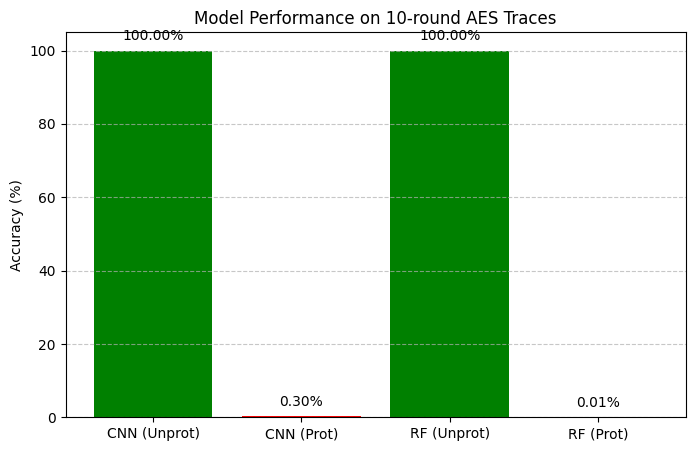

In [ ]:
import matplotlib.pyplot as plt

models = ['CNN (Unprot)', 'CNN (Prot)', 'RF (Unprot)', 'RF (Prot)']
accuracies = [100.0, 0.30, 100.0, acc_rf_prot]   # acc_rf_prot উপরে বের করেছি

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies, color=['green', 'red', 'green', 'red'])
plt.ylim(0, 105)
plt.ylabel('Accuracy (%)')
plt.title('Model Performance on 10-round AES Traces')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{acc:.2f}%', ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()